Script to compare MT model saliency scores with human annotations

Annotations are taken from the work in [REDACTED for anonymity, will be added for the camera-ready version], which can be accessed [here].

# Access and process (human) annotations, saving to file for further comparison

1. Upload the mapped annotations JSON-MIN exports locally

In [ ]:
from google.colab import files

# Upload JSON file
uploaded = files.upload()

## Saving annotations for all JSON-MIN files per sentence into sheets in Excel, taking only majority label of annotations (simultaneously removes duplicates)

Define functions

In [ ]:
import spacy
import json
import pandas as pd
from collections import Counter

def load_json_files(filenames):
    """Load data from multiple files, keeping track of which file each entry came from"""
    all_data = {}
    for filename in filenames:
        filepath = f"/content/mapped_annotations_{filename}.json"
        with open(filepath, 'r', encoding='utf-8') as f:
            file_data = json.load(f)
            for entry in file_data:
                entry['filename'] = filename  # Add filename to each entry
            all_data[filename] = file_data
    return all_data


def extract_annotations_single(entry):
    """Extract annotations for a single entry and return DataFrame"""
    text = entry['text']
    word = entry['word']
    annotator = entry['annotator']
    filename = entry['filename']

    print(f"Filename: {filename}")
    print(f"Text: {text}")
    print(f"Word: {word}")

    # Check if label exists and is not empty
    if 'label' in entry and entry['label']:
        print("Annotations:")
        for label in entry['label']:
            annotated_text = label['text']
            start = label['start']
            end = label['end']
            label_tags = label['labels']
            print(f"  - Annotated Text: '{annotated_text}' (from {start} to {end}) with labels: {label_tags}")

        df_data = []

        for label in entry['label']:
            # Filter out empty strings from labels and get non-empty labels
            valid_labels = [str(lbl).strip() for lbl in label['labels'] if str(lbl).strip()]

            # Handle person word labels
            if entry['word'] == label['text'].strip():
                # This is the person word itself
                for lbl in valid_labels:
                    df_data.append({
                        'person_word': word,
                        'person_label': lbl,
                        'source_word': '',
                        'label': ''
                    })
            else:
                # Check if text is not empty after stripping
                stripped_text = label['text'].strip()

                # Only add if text is not empty and there are valid labels
                if stripped_text and valid_labels:
                    # Split stripped_text into individual words
                    split_words = stripped_text.split()

                    # Add each valid label × each word as a separate row
                    for lbl in valid_labels:
                        for part in split_words:
                            if part.lower() not in entry['word'].lower():
                                df_data.append({
                                    'person_word': word,  # Keep for grouping, but will be emptied later
                                    'person_label': '',
                                    'source_word': part.strip(".,:\"'—.-?![]()"),
                                    'label': lbl
                                })

        df = pd.DataFrame(df_data)

    else:
        print("No annotations for this entry.")
        df = pd.DataFrame(columns=['person_word', 'person_label', 'source_word', 'label'])  # Empty DataFrame

    print(df)
    print("\n" + "="*50 + "\n")

    return df


def get_majority_label(labels):
    """Get the majority label from a list of labels, excluding 'N/A'"""
    # Filter out 'N/A' values for majority calculation
    valid_labels = [label for label in labels if label.lower() not in ['n/a', 'na', '']]

    if not valid_labels:
        # If only N/A values, return the most common one (or just 'N/A')
        return Counter(labels).most_common(1)[0][0] if labels else 'N/A'

    # Return the most common valid label
    return Counter(valid_labels).most_common(1)[0][0]


def combine_with_majority_vote(combined_dfs):
    """Combine dataframes and select majority label for each Source_word and Person_word"""
    if not combined_dfs:
        return pd.DataFrame(columns=['person_word', 'person_label', 'source_word', 'label'])

    # Combine all dataframes
    all_data = pd.concat(combined_dfs, ignore_index=True)

    # Get the person word (should be the same across all entries for this sentence)
    person_word = all_data['person_word'].iloc[0] if not all_data.empty else ''

    # Group by person_word and collect all person labels
    person_labels = all_data[all_data['person_label'] != '']['person_label'].tolist()
    majority_person_label = get_majority_label(person_labels) if person_labels else ''

    print(f"  Person word: '{person_word}' - Labels: {person_labels} - Majority: '{majority_person_label}'")

    # Group by source_word and collect all labels
    source_data = all_data[all_data['source_word'] != '']
    grouped = source_data.groupby('source_word')['label'].apply(list).reset_index()

    # Build final data
    final_data = []

    # Add person word row first (only once)
    if person_word:
        final_data.append({
            'person_word': person_word,
            'person_label': majority_person_label,
            'source_word': '',
            'label': ''
        })

    # Calculate majority label for each Source_word (with empty person columns)
    for _, row in grouped.iterrows():
        source_word = row['source_word']
        labels = row['label']
        majority_label = get_majority_label(labels)

        print(f"  Source_word: '{source_word}' - Labels: {labels} - Majority: '{majority_label}'")

        final_data.append({
            'person_word': '',
            'person_label': '',
            'source_word': source_word,
            'label': majority_label
        })

    return pd.DataFrame(final_data)

Call data and functions

In [ ]:

## Multiple files
filenames = ["000", "001", "002", "003", "004", "005", "006", "007", "008", "009",
             "010", "011", "012", "013", "014", "016", "018", "019", "020", "024", "026"] # Each ID refers to an annotator

# Load data from all specified files
all_data = load_json_files(filenames)

# Find the maximum number of entries across all files to determine how many sheets we need
max_entries = max(len(all_data[filename]) for filename in filenames)

# Modified main loop to collect dataframes and save to multi-sheet Excel
final_dataframes = []
sheet_names = []

# Process each sentence index across all files
for sentence_idx in range(max_entries):
    combined_dfs = []

    print(f"\n{'='*60}")
    print(f"PROCESSING SENTENCE {sentence_idx + 1}")
    print(f"{'='*60}")

    # For each file, get the annotations for this sentence index
    for filename in filenames:
        if sentence_idx < len(all_data[filename]):  # Check if this file has this sentence
            entry = all_data[filename][sentence_idx]
            df = extract_annotations_single(entry)
            if not df.empty:
                combined_dfs.append(df)
        else:
            print(f"Filename: {filename} - No data for sentence {sentence_idx + 1}")
            print("="*50)

    # Combine all dataframes for this sentence index with majority voting
    if combined_dfs:
        print(f"\nCALCULATING MAJORITY LABELS FOR SENTENCE {sentence_idx + 1}:")
        final_df = combine_with_majority_vote(combined_dfs)

        final_dataframes.append(final_df)
        sheet_names.append(f'Sent_{sentence_idx + 1}')

        print(f"\nCOMBINED RESULT FOR SENTENCE {sentence_idx + 1} (WITH MAJORITY VOTING):")
        print(final_df)
        print("="*60)


# Save all dataframes to different sheets in one Excel file
if final_dataframes:
    filename = f'Annotations_all_majority.xlsx'
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for df, sheet_name in zip(final_dataframes, sheet_names):
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"\nSaved {len(final_dataframes)} dataframes to '{filename}'")
    print(f"Sheet names: {sheet_names}")
else:
    print("No dataframes to save - no annotations were found.")

## Same as previous function but including only annotations that were annotated by a minimum of two annotators (agreement)

Define Functions

In [ ]:
import json
import pandas as pd
from collections import Counter

def load_json_files(filenames):
    """Load data from multiple files, keeping track of which file each entry came from"""
    all_data = {}
    for filename in filenames:
        filepath = f"/content/mapped_annotations_{filename}.json"
        with open(filepath, 'r', encoding='utf-8') as f:
            file_data = json.load(f)
            for entry in file_data:
                entry['filename'] = filename  # Add filename to each entry
            all_data[filename] = file_data
    return all_data

def extract_annotations_single(entry):
    """Extract annotations for a single entry and return DataFrame"""
    text = entry['text']
    word = entry['word']
    annotator = entry['annotator']
    filename = entry['filename']

    print(f"Filename: {filename}")
    print(f"Text: {text}")
    print(f"Word: {word}")

    # Check if label exists and is not empty
    if 'label' in entry and entry['label']:
        print("Annotations:")
        for label in entry['label']:
            annotated_text = label['text']
            start = label['start']
            end = label['end']
            label_tags = label['labels']
            print(f"  - Annotated Text: '{annotated_text}' (from {start} to {end}) with labels: {label_tags}")

        df_data = []

        for label in entry['label']:
            # Filter out empty strings from labels and get non-empty labels
            valid_labels = [str(lbl).strip() for lbl in label['labels'] if str(lbl).strip()]

            # Handle person word labels
            if entry['word'] == label['text'].strip():
                # This is the person word itself
                for lbl in valid_labels:
                    df_data.append({
                        'person_word': word,
                        'person_label': lbl,
                        'source_word': '',
                        'label': ''
                    })
            else:
                # Check if text is not empty after stripping
                stripped_text = label['text'].strip()

                # Only add if text is not empty and there are valid labels
                if stripped_text and valid_labels:
                    # Split stripped_text into individual words
                    split_words = stripped_text.split()

                    # Add each valid label × each word as a separate row
                    for lbl in valid_labels:
                        for part in split_words:
                            if part.lower() not in entry['word'].lower():
                                df_data.append({
                                    'person_word': word,  # Keep for grouping, but will be emptied later
                                    'person_label': '',
                                    'source_word': part.strip(".,:\"'—.-?![]()"),
                                    'label': lbl
                                })

        df = pd.DataFrame(df_data)

    else:
        print("No annotations for this entry.")
        df = pd.DataFrame(columns=['person_word', 'person_label', 'source_word', 'label'])  # Empty DataFrame

    print(df)
    print("\n" + "="*50 + "\n")

    return df

def get_majority_label(labels):
    """Get the majority label from a list of labels, excluding 'N/A'"""
    # Filter out 'N/A' values for majority calculation
    valid_labels = [label for label in labels if label.lower() not in ['n/a', 'na', '']]

    if not valid_labels:
        # If only N/A values, return the most common one (or just 'N/A')
        return Counter(labels).most_common(1)[0][0] if labels else 'N/A'

    # Return the most common valid label
    return Counter(valid_labels).most_common(1)[0][0]

def combine_with_majority_vote(combined_dfs):
    """Combine dataframes and select majority label for each Source_word and Person_word"""
    if not combined_dfs:
        return pd.DataFrame(columns=['person_word', 'person_label', 'source_word', 'label'])

    # Combine all dataframes
    all_data = pd.concat(combined_dfs, ignore_index=True)

    # Get the person word (should be the same across all entries for this sentence)
    person_word = all_data['person_word'].iloc[0] if not all_data.empty else ''

    # Group by person_word and collect all person labels
    person_labels = all_data[all_data['person_label'] != '']['person_label'].tolist()
    majority_person_label = get_majority_label(person_labels) if person_labels else ''

    print(f"  Person word: '{person_word}' - Labels: {person_labels} - Majority: '{majority_person_label}'")

    # Group by source_word and collect all labels
    source_data = all_data[all_data['source_word'] != '']
    grouped = source_data.groupby('source_word')['label'].apply(list).reset_index()

    # Build final data
    final_data = []

    # Add person word row first (only once)
    if person_word:
        final_data.append({
            'person_word': person_word,
            'person_label': majority_person_label,
            'source_word': '',
            'label': ''
        })

    # Calculate majority label for each Source_word (with empty person columns)
    for _, row in grouped.iterrows():
        source_word = row['source_word']
        labels = row['label']
        majority_label = get_majority_label(labels)

        print(f"  Source_word: '{source_word}' - Labels: {labels} - Majority: '{majority_label}'")

        final_data.append({
            'person_word': '',
            'person_label': '',
            'source_word': source_word,
            'label': majority_label
        })

    return pd.DataFrame(final_data)

Call data and function

In [ ]:
## Multiple files
filenames = ["000", "001", "002", "003", "004", "005", "006", "007", "008", "009",
             "010", "011", "012", "013", "014", "016", "018", "019", "020", "024", "026"]

# Load data from all specified files
all_data = load_json_files(filenames)

# Find the maximum number of entries across all files to determine how many sheets we need
max_entries = max(len(all_data[filename]) for filename in filenames)

# Modified main loop to collect dataframes and save to multi-sheet Excel
final_dataframes = []
sheet_names = []

# Process each sentence index across all files
for sentence_idx in range(max_entries):
    combined_dfs = []

    print(f"\n{'='*60}")
    print(f"PROCESSING SENTENCE {sentence_idx + 1}")
    print(f"{'='*60}")

    # For each file, get the annotations for this sentence index
    for filename in filenames:
        if sentence_idx < len(all_data[filename]):  # Check if this file has this sentence
            entry = all_data[filename][sentence_idx]
            df = extract_annotations_single(entry)
            if not df.empty:
                combined_dfs.append(df)
        else:
            print(f"Filename: {filename} - No data for sentence {sentence_idx + 1}")
            print("="*50)

    # Combine all dataframes for this sentence index with majority voting
    if combined_dfs:
        print(f"\nCALCULATING MAJORITY LABELS FOR SENTENCE {sentence_idx + 1}:")
        final_df = combine_with_majority_vote(combined_dfs)

        final_dataframes.append(final_df)
        sheet_names.append(f'Sent_{sentence_idx + 1}')

        print(f"\nCOMBINED RESULT FOR SENTENCE {sentence_idx + 1} (WITH MAJORITY VOTING):")
        print(final_df)
        print("="*60)

# Save all dataframes to different sheets in one Excel file
if final_dataframes:
    filename = f'Annotations_all_majority.xlsx'
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for df, sheet_name in zip(final_dataframes, sheet_names):
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"\nSaved {len(final_dataframes)} dataframes to '{filename}'")
    print(f"Sheet names: {sheet_names}")
else:
    print("No dataframes to save - no annotations were found.")

# Compare saliency scores with annotations

Import Excel files with saliency attribution scores, if not saved from above.

In [ ]:
from google.colab import files

# Upload JSON file
uploaded = files.upload()

## Define functions to compare annotations to attribution scores

### Define function

This function computes the overall comparison of attribution scores (Excel file with normalised attribution scores from notebook ``saliency_analysis_contrastive_gender.py``) also found in annotations (Excel file created at top of this notebook.)

In [ ]:
import pandas as pd

def complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage):
    """
    Analyse overlap between attribution scores and annotations across all sheets (from imported Excel files).

    Parameters:
    - attribution_scores: Dictionary of DataFrames from Excel sheets
    - annotations: Dictionary of DataFrames from Excel sheets
    - top_percentage: Float representing the top percentage of attribution scores (e.g. top 25% or top 10%)

    Returns:
    - summary_df: DataFrame containing summary statistics for all sentences
    """


    # Dictionary to store overlapping data for each sheet
    overlapping_data = {}

    # Get all possible sheet names from both files to ensure we process all sentences
    all_sheet_names = set(attribution_scores.keys()).union(set(annotations.keys()))

    # Compare each sheet
    for sheet_name in sorted(all_sheet_names):  # Sort to maintain consistent order
        #print(f"\nProcessing sheet: {sheet_name}")

        # Check if sheets exist in both files
        attr_exists = sheet_name in attribution_scores
        annot_exists = sheet_name in annotations

        if attr_exists and annot_exists:
            attr_df = attribution_scores[sheet_name]
            annot_df = annotations[sheet_name]

            # Check if 'Source_word' column exists in both dataframes
            if 'Source_word' in attr_df.columns and 'Source_word' in annot_df.columns:
                # Get unique values from each Source_word column
                attr_words = set(attr_df['Source_word'].dropna())
                #print(f"Salient words: {attr_words}")
                annot_words = set(annot_df['Source_word'].dropna())
                #print(f"Annotated words: {annot_words}")

                # Find overlapping words
                overlapping_words = attr_words.intersection(annot_words)
                #print(f"Overlapping words: {overlapping_words}")
                #print("")

                if overlapping_words:
                    #print(f"  Found {len(overlapping_words)} overlapping words: {overlapping_words}")

                    # Filter rows from attribution_scores where Source_word overlaps
                    attr_overlapping = attr_df[attr_df['Source_word'].isin(overlapping_words)]

                    # Filter rows from annotations where Source_word overlaps
                    annot_overlapping = annot_df[annot_df['Source_word'].isin(overlapping_words)]

                    # Create combined dataframe with overlapping data
                    # Add a column to identify the source file
                    attr_overlapping_copy = attr_overlapping.copy()
                    attr_overlapping_copy['Source_file'] = 'Attribution_Scores'

                    annot_overlapping_copy = annot_overlapping.copy()
                    annot_overlapping_copy['Source_file'] = 'Annotations'

                    # Combine both dataframes
                    combined_overlapping = pd.concat([attr_overlapping_copy, annot_overlapping_copy],
                                                  ignore_index=True, sort=False)

                    # Store in dictionary
                    overlapping_data[sheet_name] = combined_overlapping

                    #print(f"  Combined overlapping data shape: {combined_overlapping.shape}")
                    #print(f"  Columns in combined data: {combined_overlapping.columns.tolist()}")

                else:
                    # Create empty dataframe with all possible columns from both sources
                    all_columns = set()
                    if not attr_df.empty:
                        all_columns.update(attr_df.columns)
                    if not annot_df.empty:
                        all_columns.update(annot_df.columns)
                    all_columns.add('Source_file')  # Add the source file column

                    # Create empty dataframe with all columns
                    empty_df = pd.DataFrame(columns=list(all_columns))
                    overlapping_data[sheet_name] = empty_df

            else:
                # Create empty dataframe
                empty_df = pd.DataFrame(columns=['Source_word', 'Source_file'])
                overlapping_data[sheet_name] = empty_df

        elif attr_exists and not annot_exists:
            # Create empty dataframe with attribution columns plus Source_file
            attr_df = attribution_scores[sheet_name]
            columns = list(attr_df.columns) + ['Source_file']
            empty_df = pd.DataFrame(columns=columns)
            overlapping_data[sheet_name] = empty_df

        elif not attr_exists and annot_exists:
            # Create empty dataframe with annotation columns plus Source_file
            annot_df = annotations[sheet_name]
            columns = list(annot_df.columns) + ['Source_file']
            empty_df = pd.DataFrame(columns=columns)
            overlapping_data[sheet_name] = empty_df


    # Create a comprehensive summary report for ALL sentences
    summary_data_complete = []
    precision_total = 0
    overlapping_words_total = 0
    salient_words_total = 0

    for sheet_name in sorted(all_sheet_names):
        attr_total = len(attribution_scores[sheet_name]) if sheet_name in attribution_scores else 0
        annot_total = len(annotations[sheet_name]) if sheet_name in annotations else 0
        overlapping_rows = len(overlapping_data[sheet_name]) if sheet_name in overlapping_data else 0
        unique_overlapping_words = overlapping_data[sheet_name]['Source_word'].nunique() if sheet_name in overlapping_data and len(overlapping_data[sheet_name]) > 0 else 0
        #print(f"Unique overlapping words: {unique_overlapping_words}")

        # Calculate percentage based on attribution_scores if it exists, otherwise use annotations
        #print(f"Attribution total: {attr_total}")
        if attr_total == 0:
          print("Attribution total is zero.")
          precision = 0
        if attr_total > 0:
            precision = unique_overlapping_words / attr_total
            precision_total += precision
            overlapping_words_total += unique_overlapping_words
            salient_words_total += attr_total
        else:
            overlap_percentage = 0


        summary_data_complete.append({
            'Sheet': sheet_name,
            'Attribution_Total': attr_total,
            'Annotations_Total': annot_total,
            'Overlapping_Rows': overlapping_rows,
            'Unique_Overlapping_Words': unique_overlapping_words,
            'Precision': round(precision, 2)
        })

    #print("")
    #print(f"Total overlapping words: {overlapping_words_total}")
    #print(f"Total salient words: {salient_words_total}")
    micro_precision = overlapping_words_total/salient_words_total
    macro_precision = (precision_total/60)


    # Create and save summary report
    summary_df_complete = pd.DataFrame(summary_data_complete)
    #print(f"\nCOMPLETE SUMMARY REPORT (ALL {len(summary_df_complete)} SENTENCES):")
    #print(summary_df_complete)


    # Additional statistics
    total_sentences_with_overlap = len([row for row in summary_data_complete if row['Unique_Overlapping_Words'] > 0])
    total_sentences_without_overlap = len(summary_data_complete) - total_sentences_with_overlap

    print(f"\nSTATISTICS:")
    print(f"Total sentences processed: {len(summary_df_complete)}")
    print(f"Sentences with overlap: {total_sentences_with_overlap}")
    print(f"Sentences without overlap: {total_sentences_without_overlap}")
    #print(f"Average overlap percentage: {summary_df_complete['% Overlapping'].mean():.2f}%")
    print(f"Micro Precision (take sum of overlapping total/sum of salient words): {micro_precision:.3f}")
    print(f"Macro Precision (take precision for each sentence, then average): {macro_precision:.3f}")

    # Return
    return macro_precision, micro_precision


Now you can run the first function, computing the overlap and saving to Excel. It returns a dataframe with overlap results.

You have to define the two input Excel files for both attribution scores and annotations as well as define the top_percentage that you are looking at (based on attribution scores).

### For ALL annotators

DEFINE TARGET LANGUAGE

In [ ]:
target_language = "ES" # ---> Change to "DE" for German

APPROACH 1: TOP % of all words

Calculating precision

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

results_df = pd.DataFrame()

for top_percentage in [0.05, 0.1, 0.15, 0.2, 0.25]:

  if __name__ == "__main__":
      print(f"Comparison to top percentage of: {top_percentage}")
      # Load the data
      attribution_scores = pd.read_excel(f'Normalised_attribution_scores_{target_language}_{top_percentage}.xlsx', sheet_name=None)
      #top_percentage = 0.2
      annotations = pd.read_excel('Annotations_all_majority.xlsx', sheet_name=None)

      # Call the function and capture the returned DataFrame
      macro_precision, micro_precision = complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage)

      results = {
          'Threshold_%': top_percentage,
          'Macro Precision': f'{macro_precision:.4f}',
          'Micro Precision': f'{micro_precision:.4f}',
      }

      results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

      # Now you can use summary_results as a DataFrame for further analysis
      print("DataFrame returned successfully!\n---------------------------------------------------------------------------------------")

# Save ONCE after the loop completes
summary_filename = f'Summary_model-human_overlap_analysis_top_percentage_{target_language}.xlsx'
results_df.to_excel(summary_filename, index=False)
print(f"Results saved to: {summary_filename}")

APPROACH 2: TOP 1 word

Precision

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

results_df = pd.DataFrame()

if __name__ == "__main__":
    print(f"Comparison to top one word.")
    # Load the data
    attribution_scores = pd.read_excel(f'Normalised_attribution_scores_{target_language}_top_word.xlsx', sheet_name=None)
    annotations = pd.read_excel('Annotations_all_majority.xlsx', sheet_name=None)

    # Call the function and capture the returned DataFrame
    macro_precision, micro_precision = complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage)

    results = {
        'Threshold_%': top_percentage,
        'Macro Precision': f'{macro_precision:.4f}',
        'Micro Precision': f'{micro_precision:.4f}',
    }

    results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

    # Now you can use summary_results as a DataFrame for further analysis
    print("DataFrame returned successfully!\n---------------------------------------------------------------------------------------")

# Save ONCE after the loop completes
summary_filename = f'Summary_model-human_overlap_analysis_top_word_{target_language}.xlsx'
results_df.to_excel(summary_filename, index=False)
print(f"Results saved to: {summary_filename}")

APPROACH 3: WORDS WITH A MIN. ATTRIBUTION SCORE OF X

Precision

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

results_df = pd.DataFrame()

for top_percentage in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]:

  if __name__ == "__main__":
      print(f"Comparison to words with a min. attribution score of: {top_percentage}")
      # Load the data
      attribution_scores = pd.read_excel(f'Normalised_attribution_{target_language}_minimum_score_of_{top_percentage}.xlsx', sheet_name=None)
      annotations = pd.read_excel('Annotations_all_majority.xlsx', sheet_name=None)

      # Call the function and capture the returned DataFrame
      macro_precision, micro_precision = complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage)

      results = {
          'Threshold_%': top_percentage,
          'Macro Precision': f'{macro_precision:.4f}',
          'Micro Precision': f'{micro_precision:.4f}',
      }

      results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

      # Now you can use summary_results as a DataFrame for further analysis
      print("DataFrame returned successfully!\n---------------------------------------------------------------------------------------")

# Save ONCE after the loop completes
summary_filename = f'Summary_model-human_overlap_analysis_min_attribution_{target_language}.xlsx'
results_df.to_excel(summary_filename, index=False)
print(f"Results saved to: {summary_filename}")

APPROACH 4: TOP % relative to scores sum per individual sentence.

Precision

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

results_df = pd.DataFrame()

for top_percentage in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:

  if __name__ == "__main__":
      print(f"Comparison to words summed/relative to attribution scores of: {top_percentage}")
      # Load the data
      attribution_scores = pd.read_excel(f'Normalised_attribution_scores_{target_language}_sums_per_sentence_top_{top_percentage}.xlsx', sheet_name=None)
      annotations = pd.read_excel('Annotations_all_majority.xlsx', sheet_name=None)

      # Call the function and capture the returned DataFrame
      macro_precision, micro_precision = complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage)

      results = {
          'Threshold_%': top_percentage,
          'Macro Precision': f'{macro_precision:.4f}',
          'Micro Precision': f'{micro_precision:.4f}',
      }

      results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

      # Now you can use summary_results as a DataFrame for further analysis
      print("DataFrame returned successfully!\n---------------------------------------------------------------------------------------")

# Save ONCE after the loop completes
summary_filename = f'Summary_model-human_overlap_analysis_relative_attribution_{target_language}.xlsx'
results_df.to_excel(summary_filename, index=False)
print(f"Results saved to: {summary_filename}")

### For min. 2 agree Annotators

APPROACH 1

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

results_df = pd.DataFrame()

for top_percentage in [0.05, 0.1, 0.15, 0.2, 0.25]:

  if __name__ == "__main__":
      print(f"Comparison to top percentage of: {top_percentage}")
      # Load the data
      attribution_scores = pd.read_excel(f'Normalised_attribution_scores_{target_language}_{top_percentage}.xlsx', sheet_name=None)
      #top_percentage = 0.2
      annotations = pd.read_excel('All_annotations_duplicates_removed_majority_min_two_agree.xlsx', sheet_name=None)

      # Call the function and capture the returned DataFrame
      macro_precision, micro_precision = complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage)

      results = {
          'Threshold_%': top_percentage,
          'Macro Precision': f'{macro_precision:.4f}',
          'Micro Precision': f'{micro_precision:.4f}',
      }

      results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

      # Now you can use summary_results as a DataFrame for further analysis
      print("DataFrame returned successfully!\n---------------------------------------------------------------------------------------")

# Save ONCE after the loop completes
summary_filename = f'Summary_model-human-min2_overlap_analysis_top_percentage_{target_language}.xlsx'
results_df.to_excel(summary_filename, index=False)
print(f"Results saved to: {summary_filename}")

APPROACH 2

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

results_df = pd.DataFrame()

if __name__ == "__main__":
    print(f"Comparison to top one word.")
    # Load the data
    attribution_scores = pd.read_excel(f'Normalised_attribution_scores_{target_language}_top_word.xlsx', sheet_name=None)
    annotations = pd.read_excel('All_annotations_duplicates_removed_majority_min_two_agree.xlsx', sheet_name=None)

    # Call the function and capture the returned DataFrame
    macro_precision, micro_precision = complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage)

    results = {
        'Threshold_%': top_percentage,
        'Macro Precision': f'{macro_precision:.4f}',
        'Micro Precision': f'{micro_precision:.4f}',
    }

    results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

    # Now you can use summary_results as a DataFrame for further analysis
    print("DataFrame returned successfully!\n---------------------------------------------------------------------------------------")

# Save ONCE after the loop completes
summary_filename = f'Summary_model-human-min2_overlap_analysis_top_word_{target_language}.xlsx'
results_df.to_excel(summary_filename, index=False)
print(f"Results saved to: {summary_filename}")

APPROACH 3

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

results_df = pd.DataFrame()

for top_percentage in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]:

  if __name__ == "__main__":
      print(f"Comparison to words with a min. attribution score of: {top_percentage}")
      # Load the data
      attribution_scores = pd.read_excel(f'Normalised_attribution_{target_language}_minimum_score_of_{top_percentage}.xlsx', sheet_name=None)
      annotations = pd.read_excel('All_annotations_duplicates_removed_majority_min_two_agree.xlsx', sheet_name=None)

      # Call the function and capture the returned DataFrame
      macro_precision, micro_precision = complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage)

      results = {
          'Threshold_%': top_percentage,
          'Macro Precision': f'{macro_precision:.4f}',
          'Micro Precision': f'{micro_precision:.4f}',
      }

      results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

      # Now you can use summary_results as a DataFrame for further analysis
      print("DataFrame returned successfully!\n---------------------------------------------------------------------------------------")

# Save ONCE after the loop completes
summary_filename = f'Summary_model-human-min2_overlap_analysis_min_attribution_{target_language}.xlsx'
results_df.to_excel(summary_filename, index=False)
print(f"Results saved to: {summary_filename}")

APPROACH 4

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

results_df = pd.DataFrame()

for top_percentage in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:

  if __name__ == "__main__":
      print(f"Comparison to words summed/relative to attribution scores of: {top_percentage}")
      # Load the data
      attribution_scores = pd.read_excel(f'Normalised_attribution_scores_{target_language}_sums_per_sentence_top_{top_percentage}.xlsx', sheet_name=None)
      annotations = pd.read_excel('All_annotations_duplicates_removed_majority_min_two_agree.xlsx', sheet_name=None)

      # Call the function and capture the returned DataFrame
      macro_precision, micro_precision = complete_overlap_analysis_attribution_and_annotation(attribution_scores, annotations, top_percentage)

      results = {
          'Threshold_%': top_percentage,
          'Macro Precision': f'{macro_precision:.4f}',
          'Micro Precision': f'{micro_precision:.4f}',
      }

      results_df = pd.concat([results_df, pd.DataFrame([results])], ignore_index=True)

      # Now you can use summary_results as a DataFrame for further analysis
      print("DataFrame returned successfully!\n---------------------------------------------------------------------------------------")

# Save ONCE after the loop completes
summary_filename = f'Summary_model-human-min2_overlap_analysis_relative_attribution_{target_language}.xlsx'
results_df.to_excel(summary_filename, index=False)
print(f"Results saved to: {summary_filename}")

## Macro vs. Micro Precision

### For all annotators

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

overlap_min_attribution = pd.read_excel(f'Summary_model-human_overlap_analysis_min_attribution_{target_language}.xlsx')
overlap_top_word = pd.read_excel(f'Summary_model-human_overlap_analysis_top_word_{target_language}.xlsx')
overlap_relative_attribution = pd.read_excel(f'Summary_model-human_overlap_analysis_relative_attribution_{target_language}.xlsx')
overlap_top_percentage = pd.read_excel(f'Summary_model-human_overlap_analysis_top_percentage_{target_language}.xlsx')

In [ ]:
# Define x- (threshold) and y-values (precision)
# Top Percentage
top_percentage_macro_precision = overlap_top_percentage["Macro Precision"].values.tolist()
top_percentage_micro_precision = overlap_top_percentage["Micro Precision"].values.tolist()
top_percentage_threshold = overlap_top_percentage["Threshold_%"].values.tolist()

# Top word
overlap_top_word_macro_precision = overlap_top_word["Macro Precision"].values.tolist()
overlap_top_word_micro_precision = overlap_top_word["Micro Precision"].values.tolist()
overlap_top_word_threshold = overlap_top_word["Threshold_%"].values.tolist()

# Minimum attribution score
min_attribution_macro_precision = overlap_min_attribution["Macro Precision"].values.tolist()
min_attribution_micro_precision = overlap_min_attribution["Micro Precision"].values.tolist()
min_attribution_threshold = overlap_min_attribution["Threshold_%"].values.tolist()

# Relative attribution score
relative_attribution_macro_precision = overlap_relative_attribution["Macro Precision"].values.tolist()
relative_attribution_micro_precision = overlap_relative_attribution["Micro Precision"].values.tolist()
relative_attribution_threshold = overlap_relative_attribution["Threshold_%"].values.tolist()

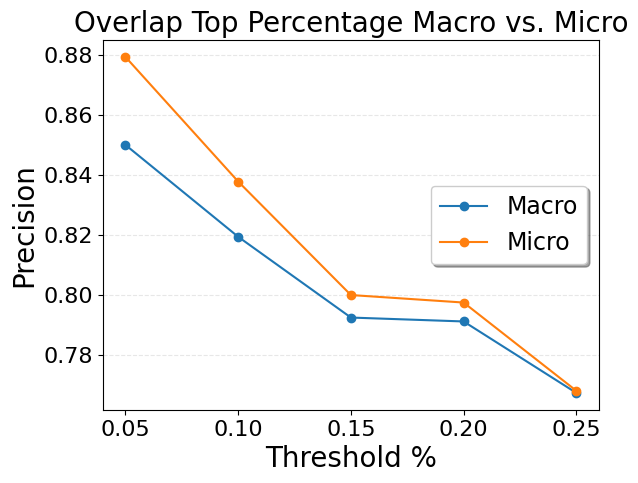

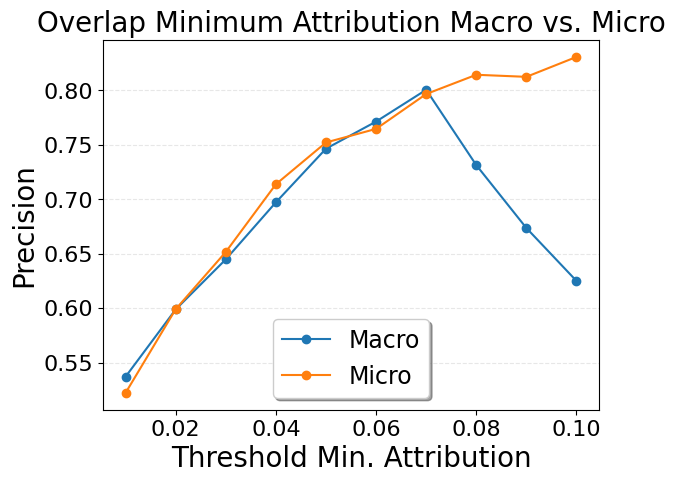

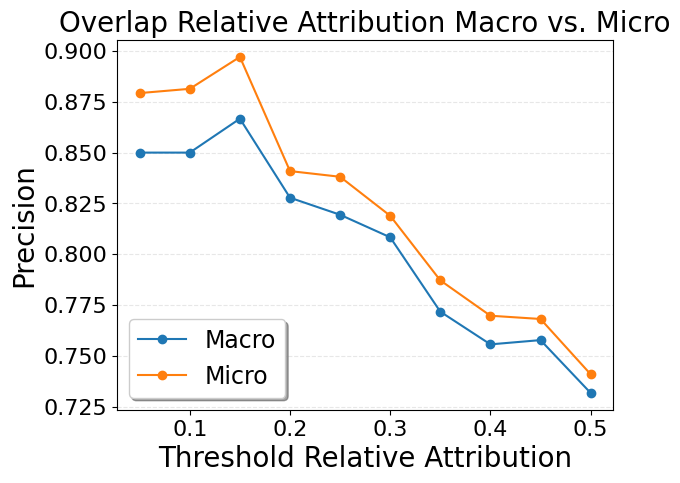

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

## Top Percentage
fig, ax = plt.subplots()
ax.plot(top_percentage_threshold, top_percentage_macro_precision, marker='o')
ax.plot(top_percentage_threshold, top_percentage_micro_precision, marker='o')
plt.title('Overlap Top Percentage Macro vs. Micro', fontsize=20, fontweight='medium')
plt.xlabel('Threshold %', fontsize=20, fontweight='medium')
plt.ylabel('Precision', fontsize=20, fontweight='medium')
plt.legend(['Macro', 'Micro'], loc='center right', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

plt.savefig(f"micro_vs_macro_overlap_top_percentage_{target_language}.jpg")
plt.show()
print("")


## Minimum Attribution Score
fig, ax = plt.subplots()
ax.plot(min_attribution_threshold, min_attribution_macro_precision, marker='o')
ax.plot(min_attribution_threshold, min_attribution_micro_precision, marker='o')
plt.title('Overlap Minimum Attribution Macro vs. Micro', fontsize=20, fontweight='medium')
plt.xlabel('Threshold Min. Attribution', fontsize=20, fontweight='medium')
plt.ylabel('Precision', fontsize=20, fontweight='medium')
plt.legend(['Macro', 'Micro'], loc='lower center', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

plt.savefig(f"micro_vs_macro_overlap_min_attribution_{target_language}.jpg")
plt.show()
print("")


## Relative Attribution Score
fig, ax = plt.subplots()
ax.plot(relative_attribution_threshold, relative_attribution_macro_precision, marker='o')
ax.plot(relative_attribution_threshold, relative_attribution_micro_precision, marker='o')
plt.title('Overlap Relative Attribution Macro vs. Micro', fontsize=20, fontweight='medium')
plt.xlabel('Threshold Relative Attribution', fontsize=20, fontweight='medium')
plt.ylabel('Precision', fontsize=20, fontweight='medium')
plt.legend(['Macro', 'Micro'], loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

plt.savefig(f"micro_vs_macro_overlap_relative_attribution_{target_language}.jpg")
plt.show()
print("")

### For min2 agree

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

overlap_min_attribution = pd.read_excel(f'Summary_model-human-min2_overlap_analysis_min_attribution_{target_language}.xlsx')
overlap_top_word = pd.read_excel(f'Summary_model-human-min2_overlap_analysis_top_word_{target_language}.xlsx')
overlap_relative_attribution = pd.read_excel(f'Summary_model-human-min2_overlap_analysis_relative_attribution_{target_language}.xlsx')
overlap_top_percentage = pd.read_excel(f'Summary_model-human-min2_overlap_analysis_top_percentage_{target_language}.xlsx')

In [ ]:
# Define x- (threshold) and y-values (precision)
# Top Percentage
top_percentage_macro_precision = overlap_top_percentage["Macro Precision"].values.tolist()
top_percentage_micro_precision = overlap_top_percentage["Micro Precision"].values.tolist()
top_percentage_threshold = overlap_top_percentage["Threshold_%"].values.tolist()

# Top word
overlap_top_word_macro_precision = overlap_top_word["Macro Precision"].values.tolist()
overlap_top_word_micro_precision = overlap_top_word["Micro Precision"].values.tolist()
overlap_top_word_threshold = overlap_top_word["Threshold_%"].values.tolist()

# Minimum attribution score
min_attribution_macro_precision = overlap_min_attribution["Macro Precision"].values.tolist()
min_attribution_micro_precision = overlap_min_attribution["Micro Precision"].values.tolist()
min_attribution_threshold = overlap_min_attribution["Threshold_%"].values.tolist()

# Relative attribution score
relative_attribution_macro_precision = overlap_relative_attribution["Macro Precision"].values.tolist()
relative_attribution_micro_precision = overlap_relative_attribution["Micro Precision"].values.tolist()
relative_attribution_threshold = overlap_relative_attribution["Threshold_%"].values.tolist()

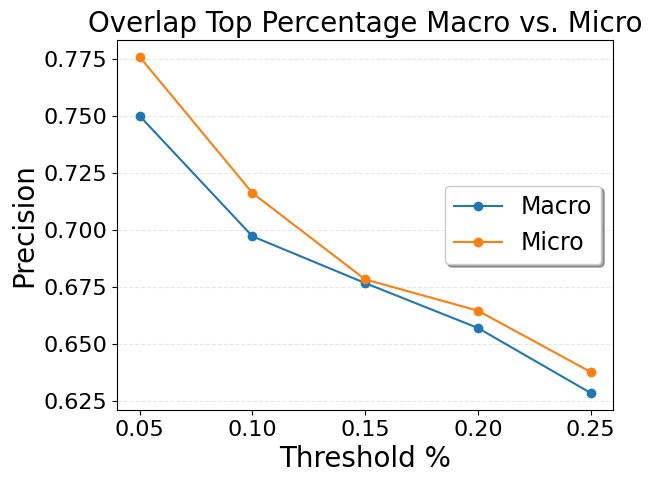

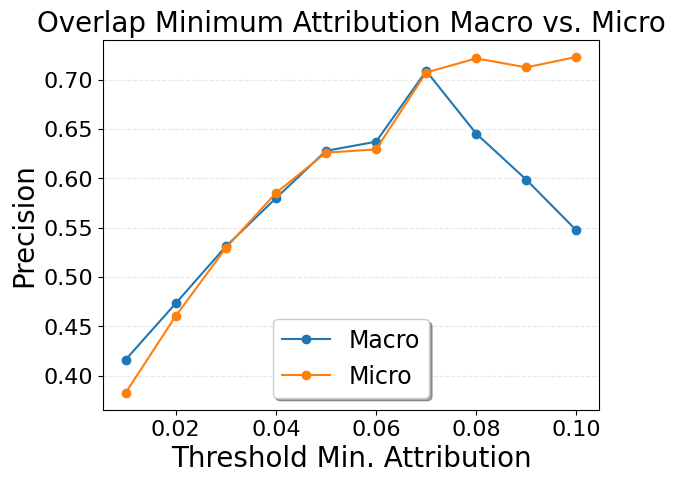

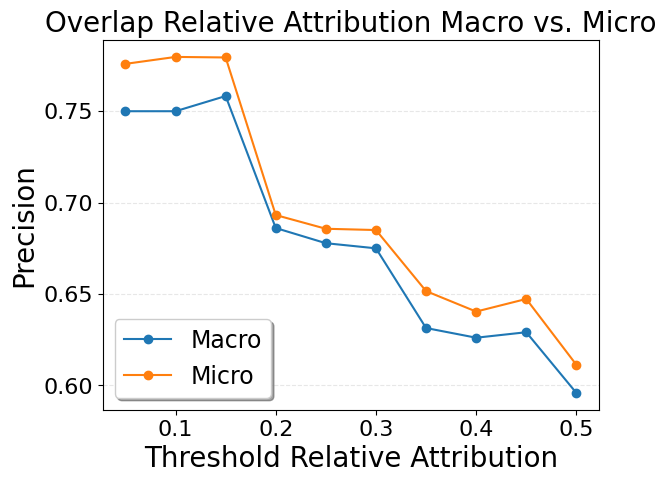

In [ ]:
print(f"############ Processing for target language: {target_language}. ############ \n")

## Top Percentage
fig, ax = plt.subplots()
ax.plot(top_percentage_threshold, top_percentage_macro_precision, marker='o')
ax.plot(top_percentage_threshold, top_percentage_micro_precision, marker='o')
plt.title('Overlap Top Percentage Macro vs. Micro', fontsize=20, fontweight='medium')
plt.xlabel('Threshold %', fontsize=20, fontweight='medium')
plt.ylabel('Precision', fontsize=20, fontweight='medium')
plt.legend(['Macro', 'Micro'], loc='center right', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

plt.show()
print("")


## Minimum Attribution Score
fig, ax = plt.subplots()
ax.plot(min_attribution_threshold, min_attribution_macro_precision, marker='o')
ax.plot(min_attribution_threshold, min_attribution_micro_precision, marker='o')
plt.title('Overlap Minimum Attribution Macro vs. Micro', fontsize=20, fontweight='medium')
plt.xlabel('Threshold Min. Attribution', fontsize=20, fontweight='medium')
plt.ylabel('Precision', fontsize=20, fontweight='medium')
plt.legend(['Macro', 'Micro'], loc='lower center', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

plt.show()
print("")


## Relative Attribution Score
fig, ax = plt.subplots()
ax.plot(relative_attributionthreshold, relative_attribution_macro_precision, marker='o')
ax.plot(relative_attribution_threshold, relative_attribution_micro_precision, marker='o')
plt.title('Overlap Relative Attribution Macro vs. Micro', fontsize=20, fontweight='medium')
plt.xlabel('Threshold Relative Attribution', fontsize=20, fontweight='medium')
plt.ylabel('Precision', fontsize=20, fontweight='medium')
plt.legend(['Macro', 'Micro'], loc='lower left', frameon=True, fancybox=True, shadow=True, fontsize=17)
plt.grid(axis='y', alpha=0.3, linestyle='--') # Add grid for better readability
ax.tick_params(axis='both', which='major', labelsize=16)  # set font size for ticks

plt.show()
print("")